# Exploratory Data Analysis (EDA) – Mutual Fund Analytics

This notebook presents exploratory data analysis for the Mutual Fund Analytics capstone project. It covers NAV trends, AUM growth, SIP inflows, investor demographics, geographic distribution, folio growth, fund return correlations, portfolio sector allocation, and additional supporting insights.

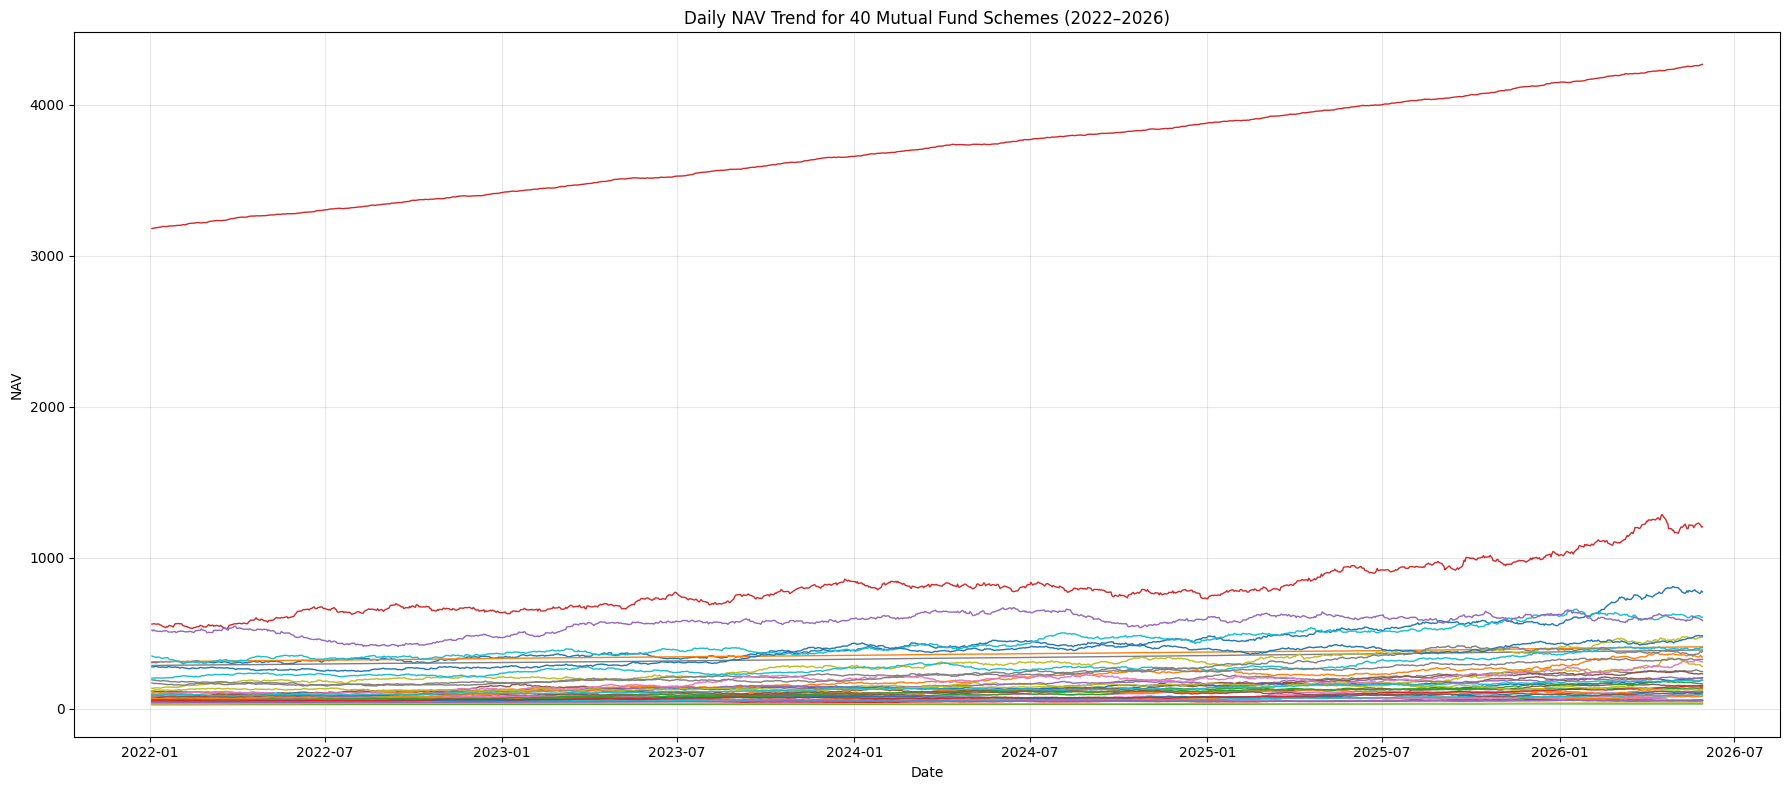

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
nav = pd.read_csv("data/processed/nav_history_cleaned.csv")
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Merge scheme names from fund master
nav = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Sort values
nav = nav.sort_values(["scheme_name", "date"])

# Plot
plt.figure(figsize=(18, 8))
for scheme in nav["scheme_name"].dropna().unique():
    df_scheme = nav[nav["scheme_name"] == scheme]
    plt.plot(df_scheme["date"], df_scheme["nav"], linewidth=1)

plt.title("Daily NAV Trend for 40 Mutual Fund Schemes (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### NAV Trend Analysis
This chart shows the daily NAV movement of all 40 mutual fund schemes from 2022 to 2026. It helps identify broad uptrends, corrections, and relative growth behaviour across schemes.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
aum["date"] = pd.to_datetime(aum["date"])

# If the file has yearly values, inspect columns first
print(aum.columns)
print(aum.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0 2022-03-31      SBI Mutual Fund            6.05     605000          186
1 2022-03-31  ICICI Prudential MF            4.65     465000          216
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195
3 2022-03-31      Nippon India MF            2.70     270000          177
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168


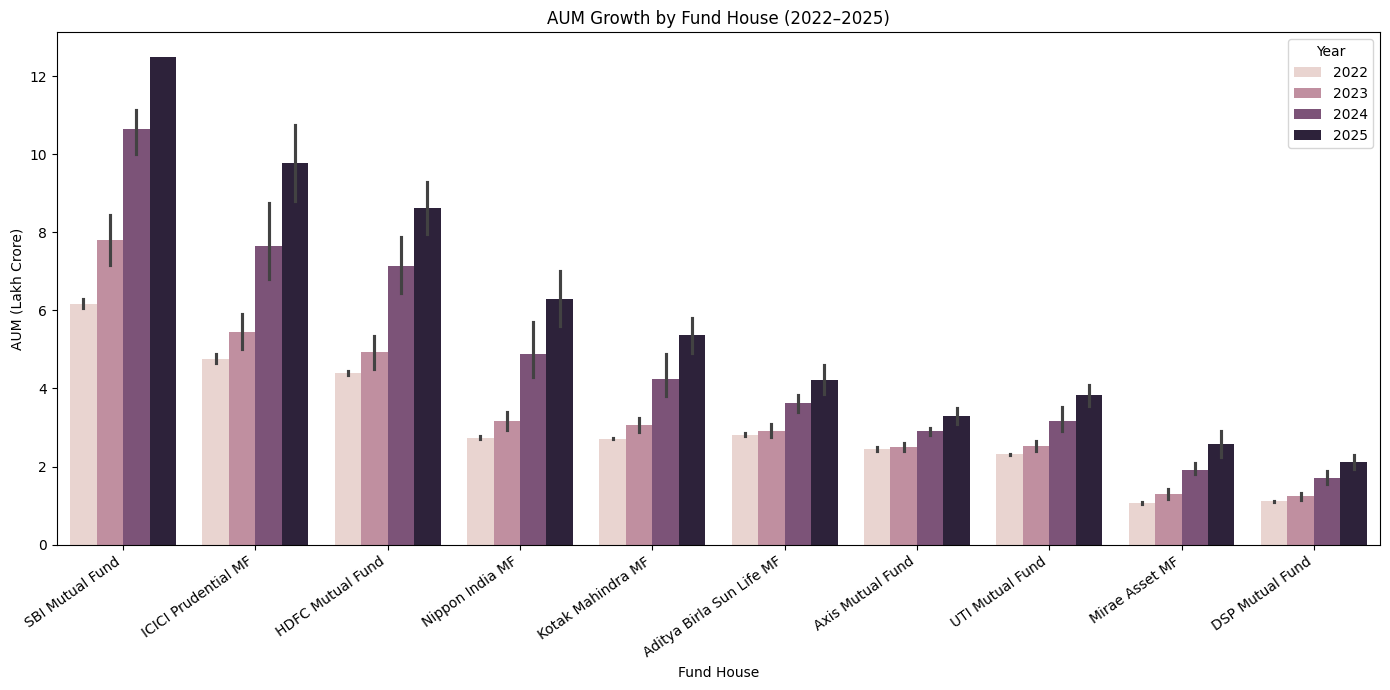

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

# Keep only 2022–2025
aum = aum[aum["year"].between(2022, 2025)]

# Use lakh crore for cleaner scale
plt.figure(figsize=(14, 7))
sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [10]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
print(sip.columns)
print(sip.head())

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


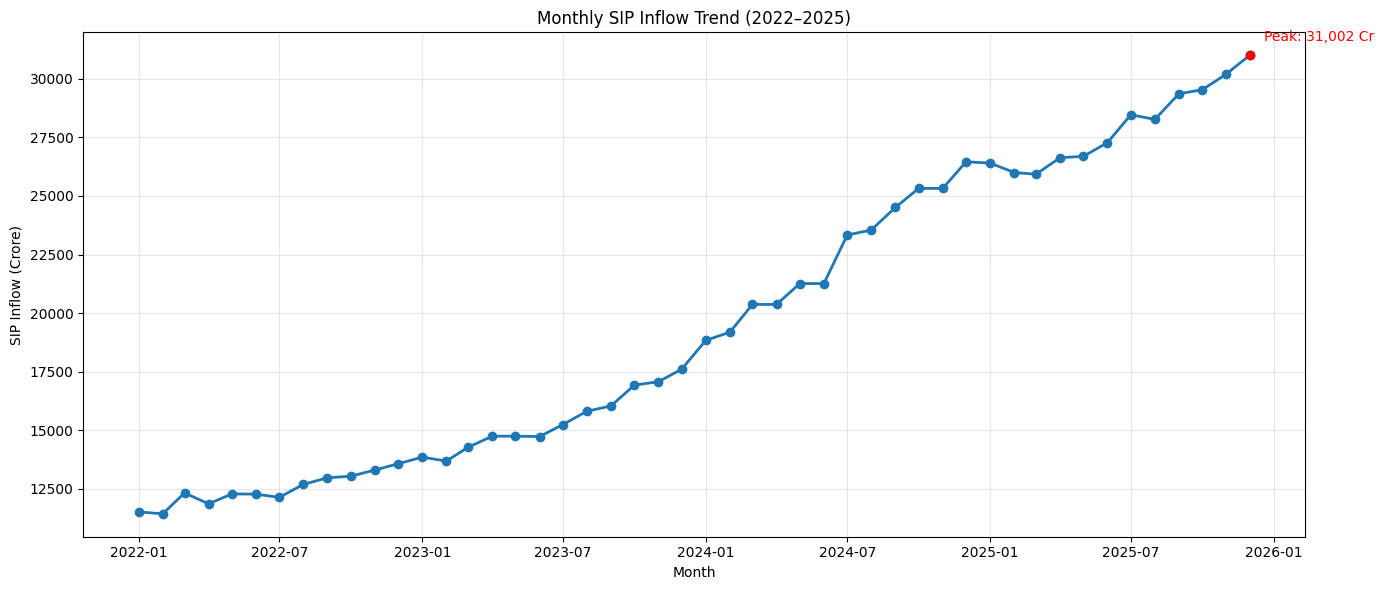

In [11]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14, 6))
plt.plot(sip["month"], sip["sip_inflow_crore"], marker="o", linewidth=2)

# Highlight max point
max_idx = sip["sip_inflow_crore"].idxmax()
max_row = sip.loc[max_idx]
plt.scatter(max_row["month"], max_row["sip_inflow_crore"], color="red", zorder=5)
plt.annotate(
    f'Peak: {int(max_row["sip_inflow_crore"]):,} Cr',
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(10, 10),
    textcoords="offset points",
    color="red"
)

plt.title("Monthly SIP Inflow Trend (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### SIP Inflow Time-Series
This line chart tracks monthly SIP inflows from January 2022 to December 2025. It shows the sustained rise in retail participation and marks the highest SIP inflow month.

In [12]:
cat = pd.read_csv("data/raw/05_category_inflows.csv")
print(cat.columns)
print(cat.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='object')
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


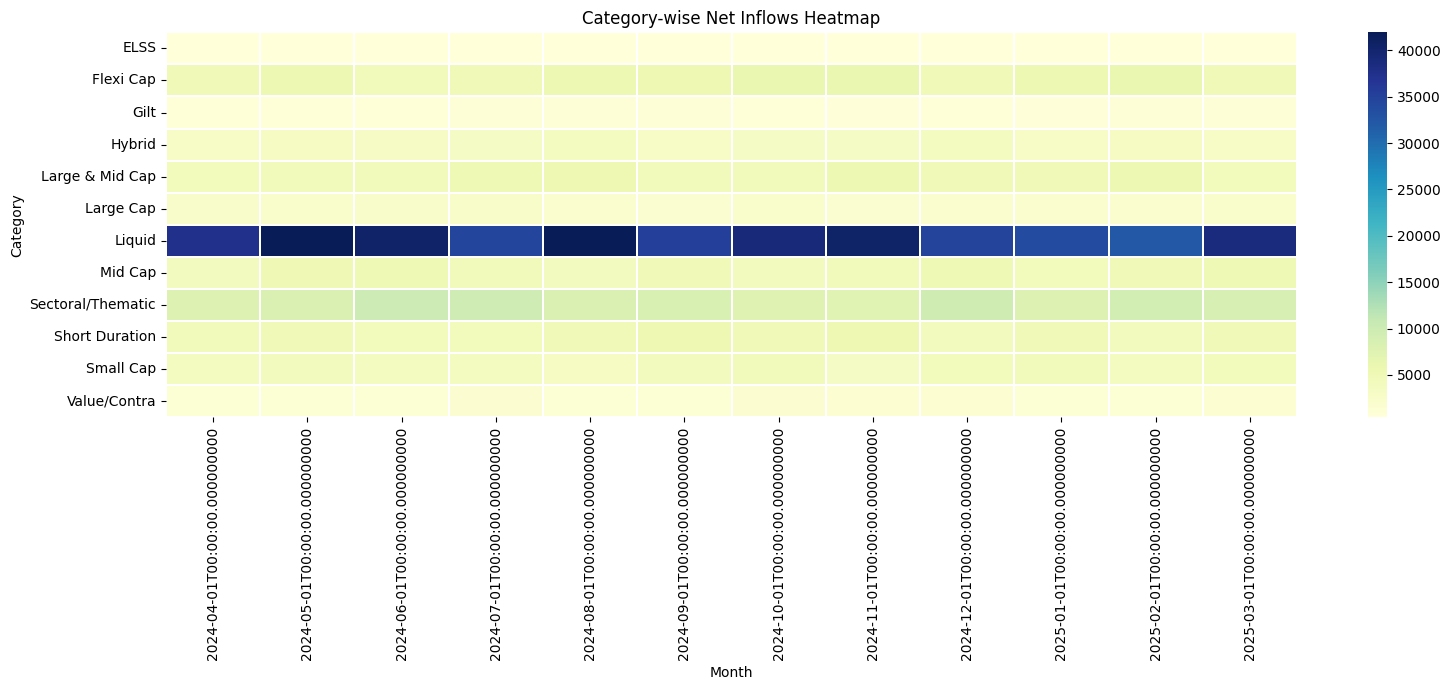

In [13]:
cat = pd.read_csv("data/raw/05_category_inflows.csv")
cat["month"] = pd.to_datetime(cat["month"])

pivot = cat.pivot(index="category", columns="month", values="net_inflow_crore")

plt.figure(figsize=(16, 7))
sns.heatmap(pivot, cmap="YlGnBu", linewidths=0.3)
plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Category-wise Inflow Heatmap
This heatmap compares monthly net inflows across fund categories. It makes it easy to spot which categories attracted the strongest investor money over time.

In [17]:
tx = pd.read_csv("data/processed/investor_transactions_cleaned.csv")
print(tx.columns)
print(tx.head())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra  

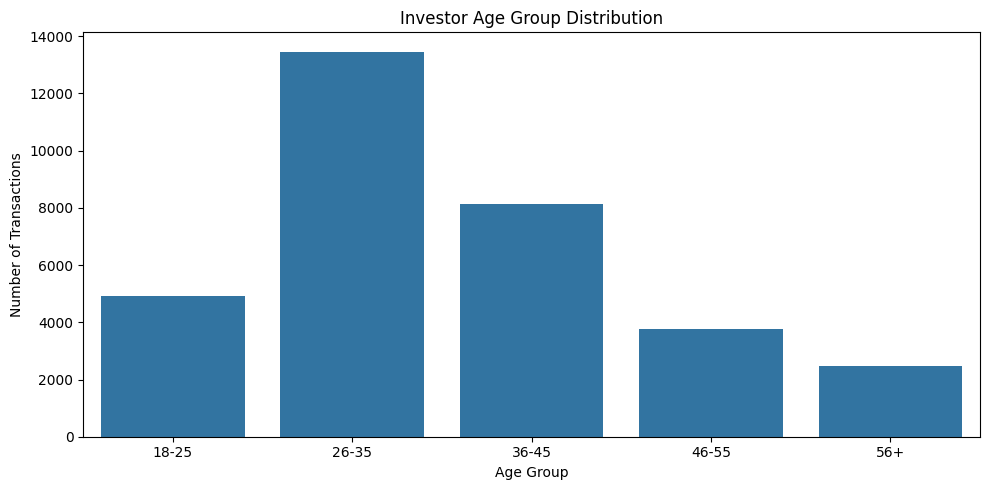

In [18]:
tx = pd.read_csv("data/processed/investor_transactions_cleaned.csv")

plt.figure(figsize=(10, 5))
order = ["18-25", "26-35", "36-45", "46-55", "56+"]
sns.countplot(data=tx, x="age_group", order=order)
plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Investor Age Distribution
This chart shows the concentration of mutual fund activity across age groups. It helps identify which investor segment contributes most to transaction volume.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4196\1412388178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tx, x="age_group", order=age_order, palette="Blues")


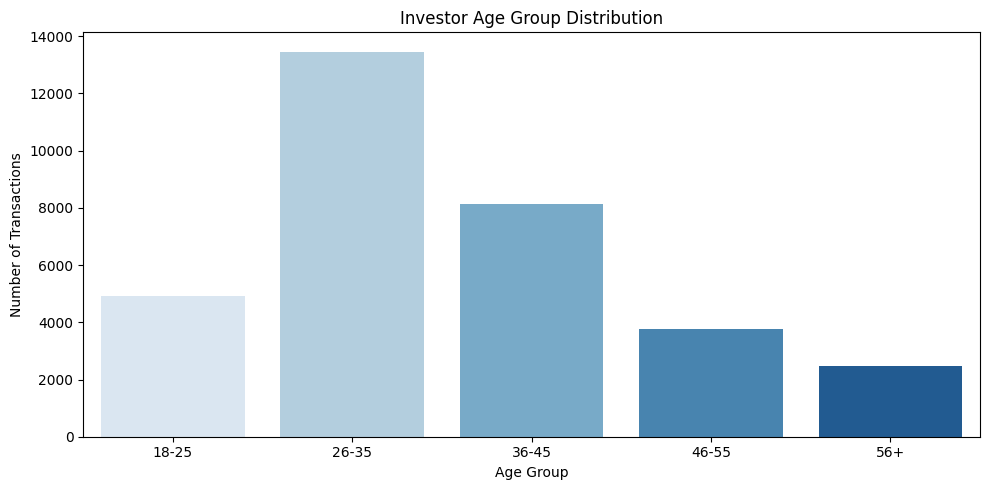

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tx = pd.read_csv("data/processed/investor_transactions_cleaned.csv")

age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]

plt.figure(figsize=(10, 5))
sns.countplot(data=tx, x="age_group", order=age_order, palette="Blues")
plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Investor Age Distribution
This chart shows the concentration of mutual fund activity across age groups. It helps identify which investor segment contributes most to transaction volume.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4196\969291259.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", order=age_order, palette="Set2")


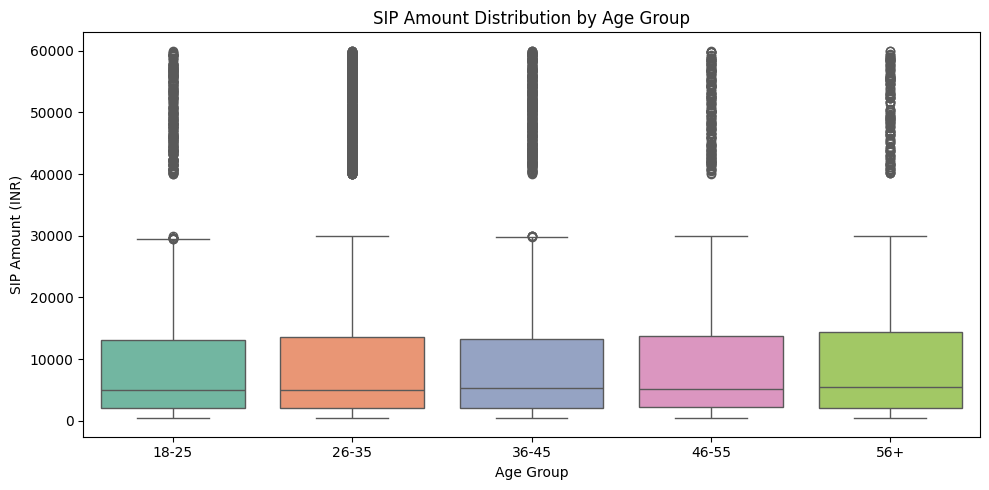

In [20]:
sip_tx = tx[tx["transaction_type"].str.lower() == "sip"].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", order=age_order, palette="Set2")
plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")
plt.tight_layout()
plt.show()

### SIP Amount by Age Group
This box plot compares SIP transaction amounts across investor age groups. It helps reveal differences in contribution behaviour and spread across segments.

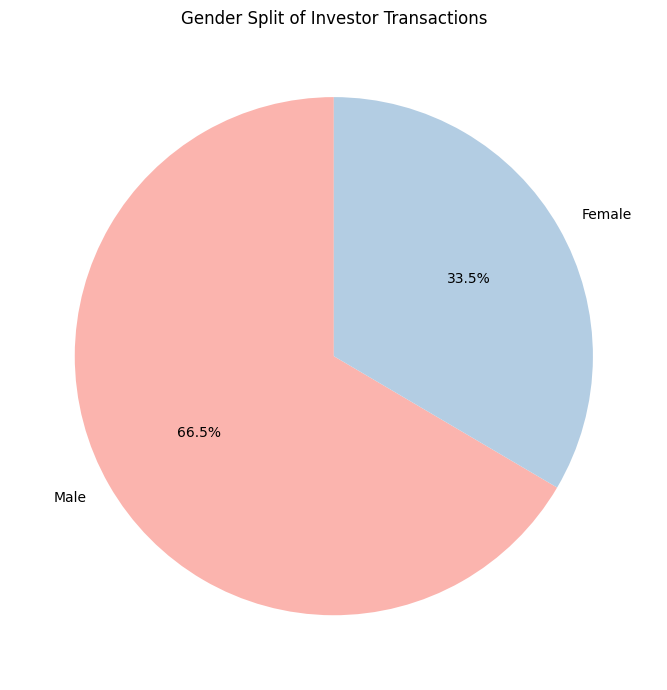

In [21]:
gender_counts = tx["gender"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Pastel1", len(gender_counts))
)
plt.title("Gender Split of Investor Transactions")
plt.tight_layout()
plt.show()

### Gender Split
This pie chart shows the transaction distribution by gender. It provides a quick view of participation balance across investor groups.

In [22]:
print(tx.columns)
print(tx[["state", "city_tier", "amount_inr"]].head())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
         state city_tier  amount_inr
0    Telangana       T30        1834
1       Punjab       B30      392882
2      Haryana       B30         912
3  Maharashtra       T30        1102
4        Delhi       T30        8682


C:\Users\lenovo\AppData\Local\Temp\ipykernel_4196\4164608430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_amt, y="state", x="amount_inr", palette="viridis")


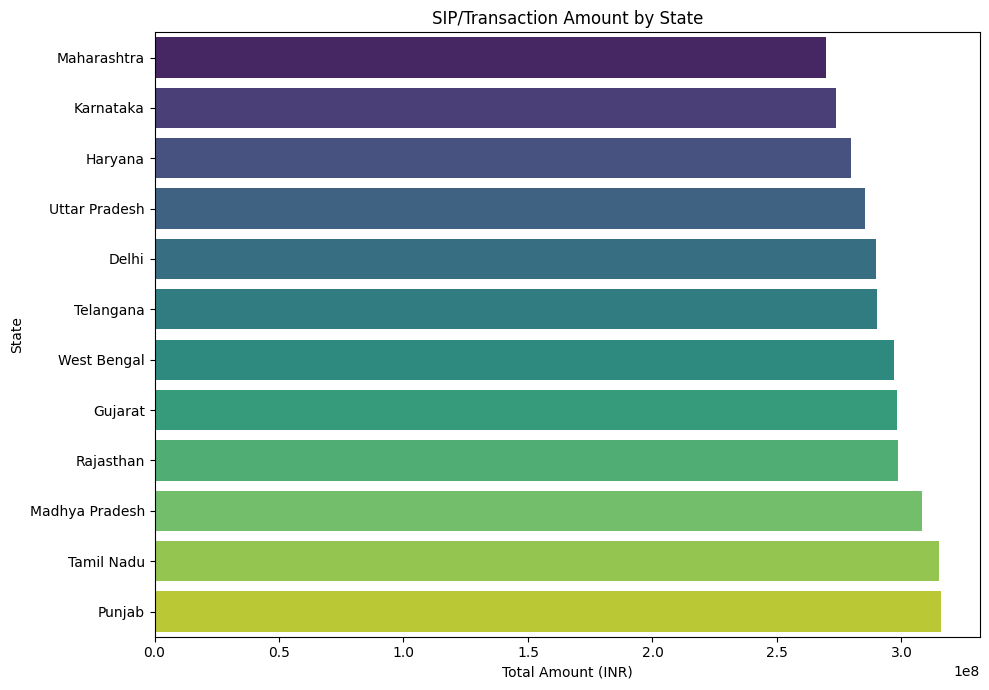

In [23]:
state_amt = tx.groupby("state", as_index=False)["amount_inr"].sum().sort_values("amount_inr", ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(data=state_amt, y="state", x="amount_inr", palette="viridis")
plt.title("SIP/Transaction Amount by State")
plt.xlabel("Total Amount (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Geographic Distribution by State
This horizontal bar chart shows which states contribute the most transaction value. It highlights regional concentration of investor activity.

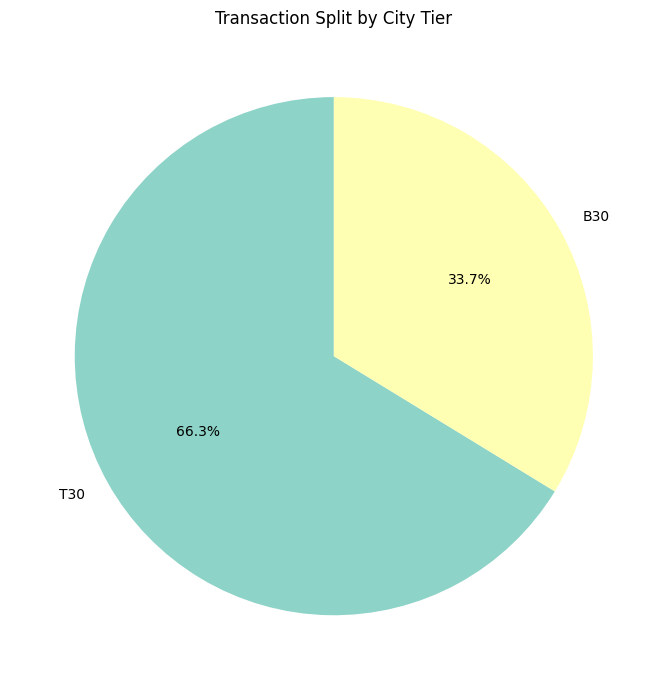

In [24]:
tier_counts = tx["city_tier"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3", len(tier_counts))
)
plt.title("Transaction Split by City Tier")
plt.tight_layout()
plt.show()

### T30 vs B30 City Tier Split
This pie chart compares transaction activity between T30 and B30 cities. It helps show whether investment participation is concentrated in larger metros or smaller cities.

In [25]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
print(folio.columns)
print(folio.head())

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


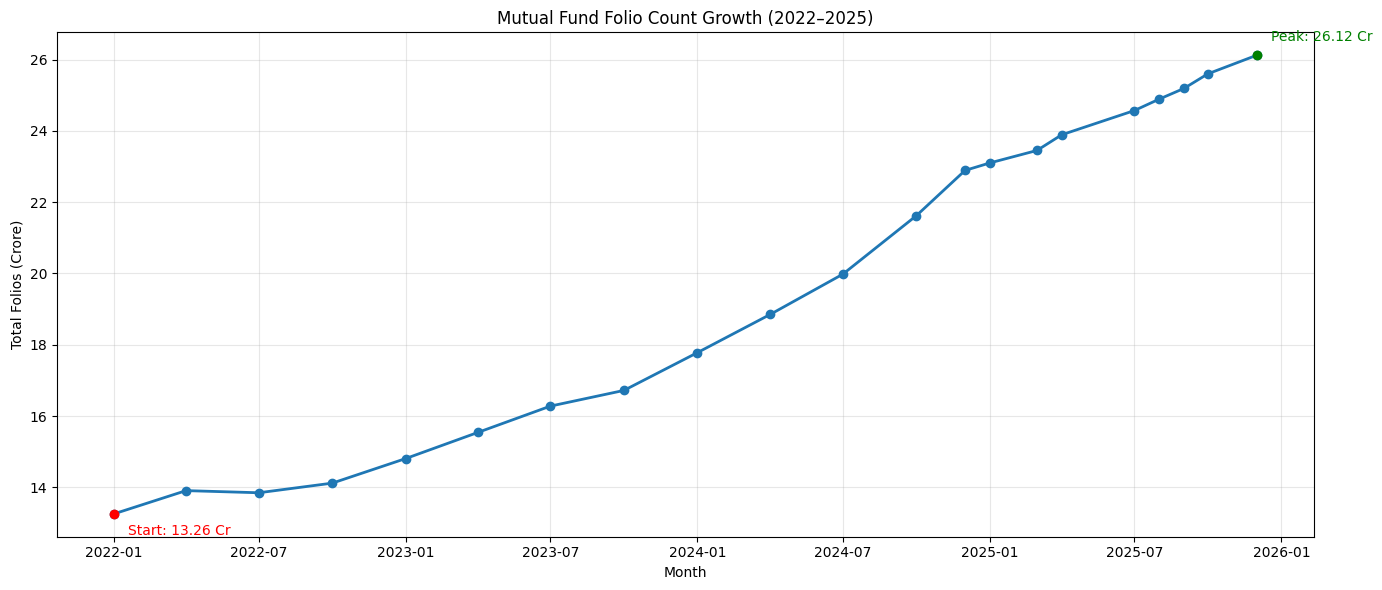

In [26]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14, 6))
plt.plot(folio["month"], folio["total_folios_crore"], marker="o", linewidth=2)

min_row = folio.loc[folio["total_folios_crore"].idxmin()]
max_row = folio.loc[folio["total_folios_crore"].idxmax()]

plt.scatter(min_row["month"], min_row["total_folios_crore"], color="red", zorder=5)
plt.scatter(max_row["month"], max_row["total_folios_crore"], color="green", zorder=5)

plt.annotate(
    f'Start: {min_row["total_folios_crore"]:.2f} Cr',
    xy=(min_row["month"], min_row["total_folios_crore"]),
    xytext=(10, -15),
    textcoords="offset points",
    color="red"
)
plt.annotate(
    f'Peak: {max_row["total_folios_crore"]:.2f} Cr',
    xy=(max_row["month"], max_row["total_folios_crore"]),
    xytext=(10, 10),
    textcoords="offset points",
    color="green"
)

plt.title("Mutual Fund Folio Count Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Folio Count Growth
This line chart shows the growth in total mutual fund folios from 2022 to 2025. It highlights the steady expansion in retail participation across the industry.

In [27]:
nav = pd.read_csv("data/raw/02_nav_history.csv")  # or your cleaned nav file if that's the one you use
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

print(nav.columns)
print(fund_master.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


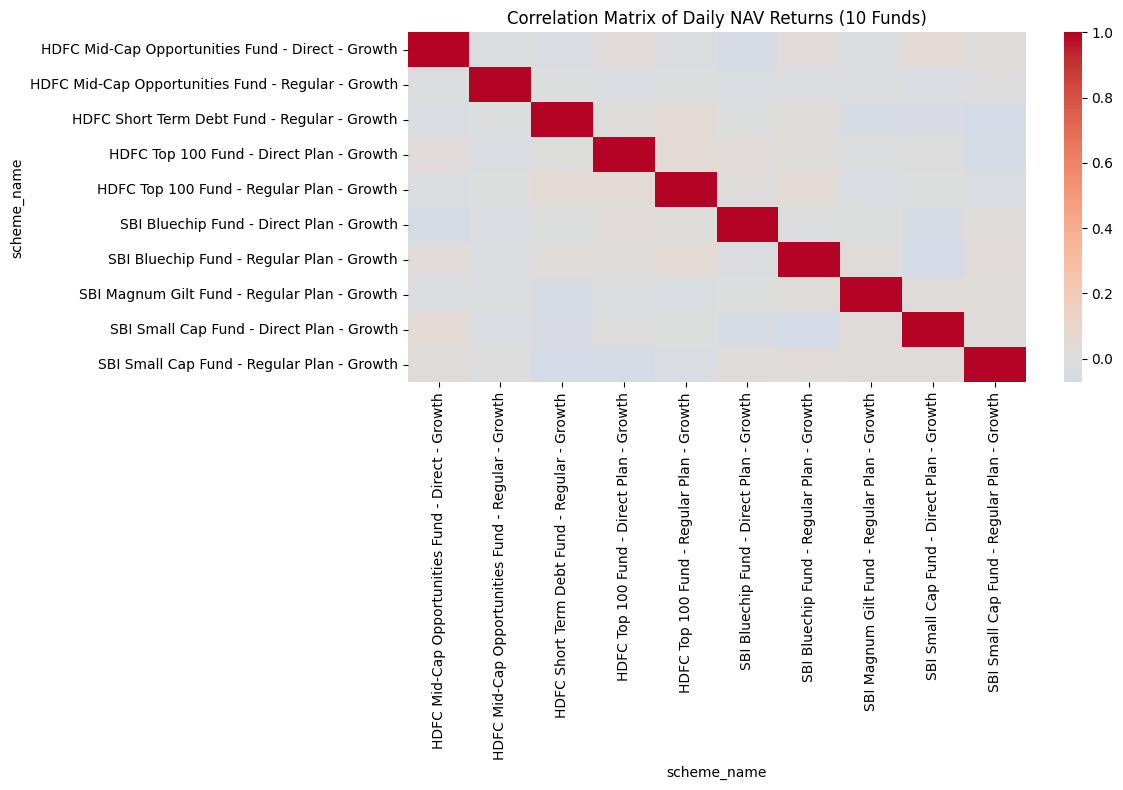

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("data/raw/02_nav_history.csv")
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

selected_codes = fund_master["amfi_code"].head(10).tolist()

nav_sel = nav[nav["amfi_code"].isin(selected_codes)].copy()
nav_sel = nav_sel.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_sel = nav_sel.sort_values(["amfi_code", "date"])
nav_sel["daily_return"] = nav_sel.groupby("amfi_code")["nav"].pct_change()

corr_df = nav_sel.pivot(index="date", columns="scheme_name", values="daily_return").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix of Daily NAV Returns (10 Funds)")
plt.tight_layout()
plt.show()

### NAV Return Correlation Matrix
This heatmap shows how closely the daily returns of the selected funds move together. It helps identify diversification overlap among mutual fund schemes.

In [29]:
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")
print(holdings.columns)
print(holdings.head())

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


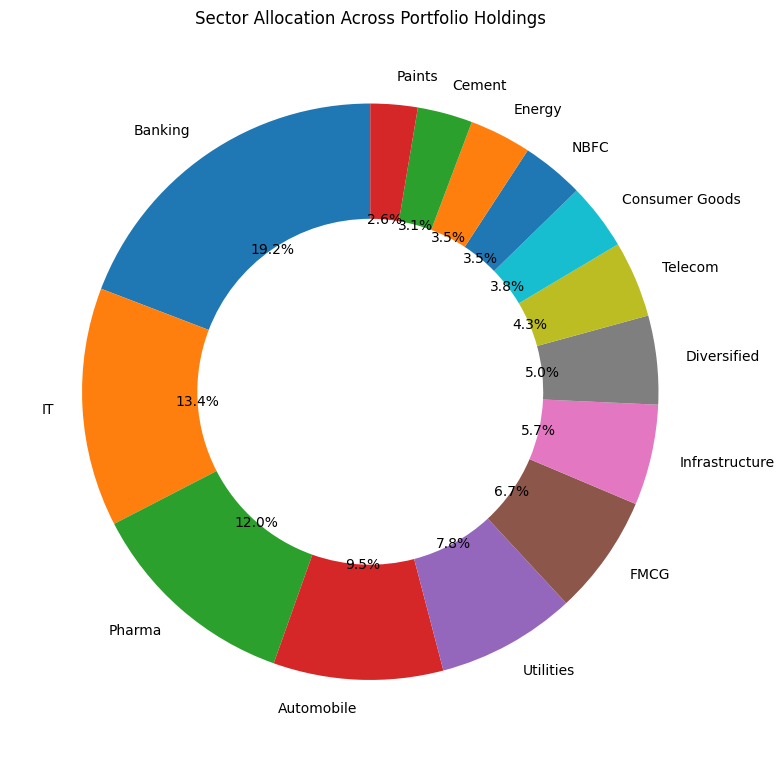

In [30]:
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

sector_weights = (
    holdings.groupby("sector", as_index=False)["weight_pct"]
    .sum()
    .sort_values("weight_pct", ascending=False)
)

plt.figure(figsize=(8, 8))
plt.pie(
    sector_weights["weight_pct"],
    labels=sector_weights["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)
plt.title("Sector Allocation Across Portfolio Holdings")
plt.tight_layout()
plt.show()

### Sector Allocation Donut
This donut chart aggregates sector weights across the portfolio holdings. It shows which sectors dominate equity fund portfolios and where concentration risk may exist.

## Key EDA Findings

1. NAVs across all 40 schemes show a consistent upward drift from 2022 to 2026, indicating broad market growth.
2. SBI Mutual Fund leads AUM among the top fund houses, and its advantage widens over time.
3. Monthly SIP inflows rise steadily through 2022–2025, reaching the highest level at the end of the series.
4. Mid Cap and Flexi Cap categories attract the strongest inflows in the category heatmap.
5. Investors aged 26–35 account for the largest transaction volume.
6. SIP ticket sizes vary across age groups, but no age band dominates strongly in the box plot.
7. Male investors form a larger share of transactions than female investors in the dataset.
8. Maharashtra and a few major states contribute the highest transaction values.
9. T30 cities account for the majority of transaction activity compared with B30 cities.
10. Portfolio holdings show meaningful sector concentration, with a few sectors accounting for a large share of total weight.

## Additional Supporting Visuals
The following charts extend the analysis and help meet the expanded visual deliverable requirement.

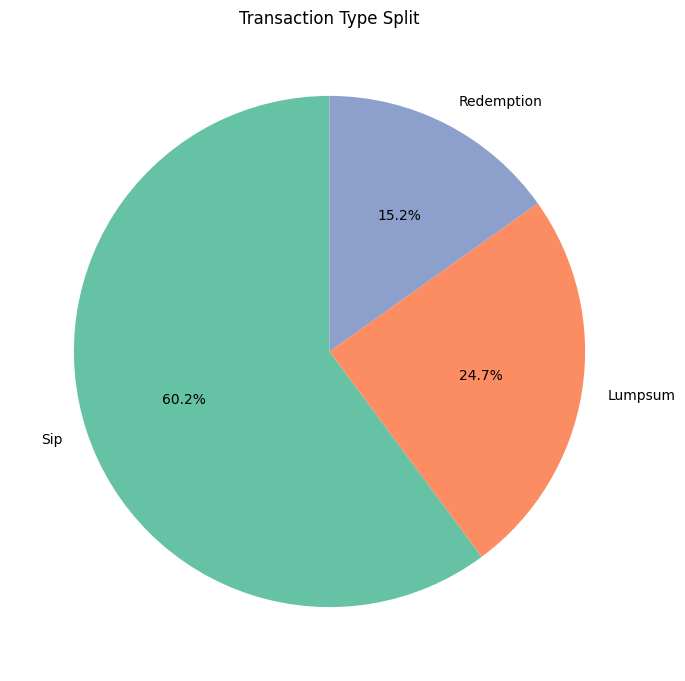

In [31]:
plt.figure(figsize=(7, 7))
tx["transaction_type"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2")
)
plt.title("Transaction Type Split")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Transaction Type Split
This pie chart shows how investor activity is divided across SIP, lumpsum, and redemption transactions.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4196\2813608148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tx, y="payment_mode", order=tx["payment_mode"].value_counts().index, palette="magma")


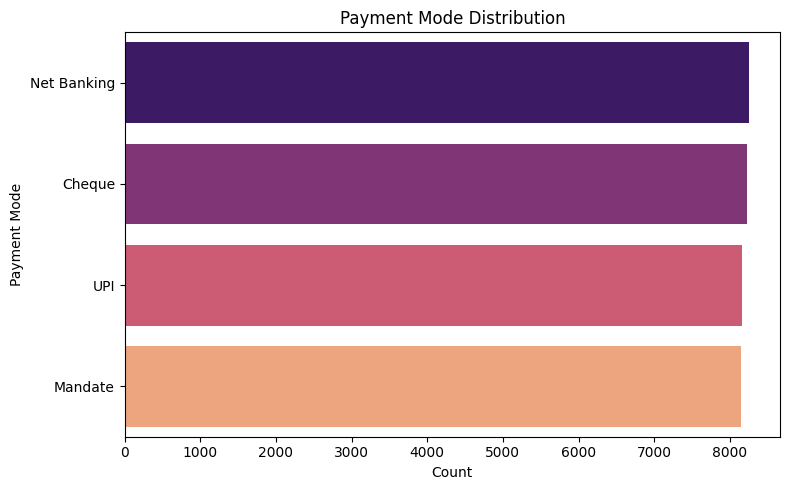

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(data=tx, y="payment_mode", order=tx["payment_mode"].value_counts().index, palette="magma")
plt.title("Payment Mode Distribution")
plt.xlabel("Count")
plt.ylabel("Payment Mode")
plt.tight_layout()
plt.show()

### Payment Mode Distribution
This bar chart shows which payment modes are most commonly used by investors.

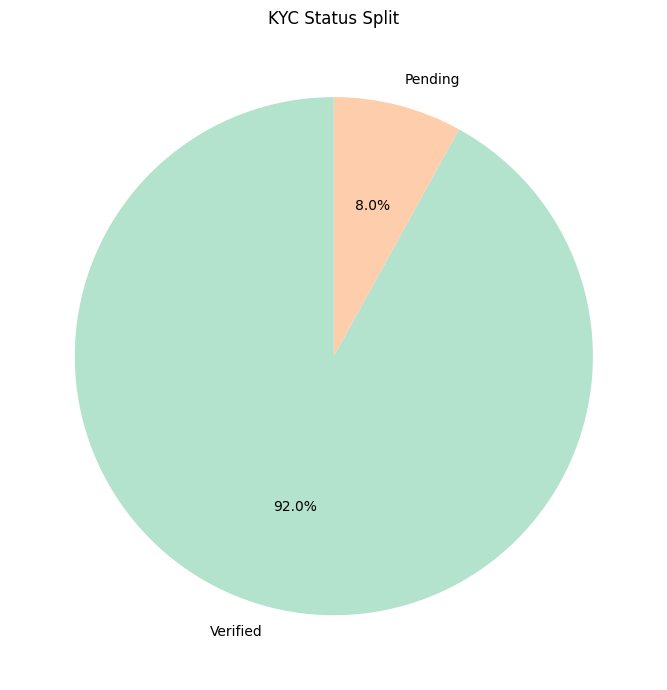

In [34]:
plt.figure(figsize=(7, 7))
tx["kyc_status"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Pastel2")
)
plt.title("KYC Status Split")
plt.ylabel("")
plt.tight_layout()
plt.show()

### KYC Status Split
This pie chart shows the proportion of verified and pending KYC records in the dataset.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4196\131848470.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x="amount_inr", y="state", palette="crest")


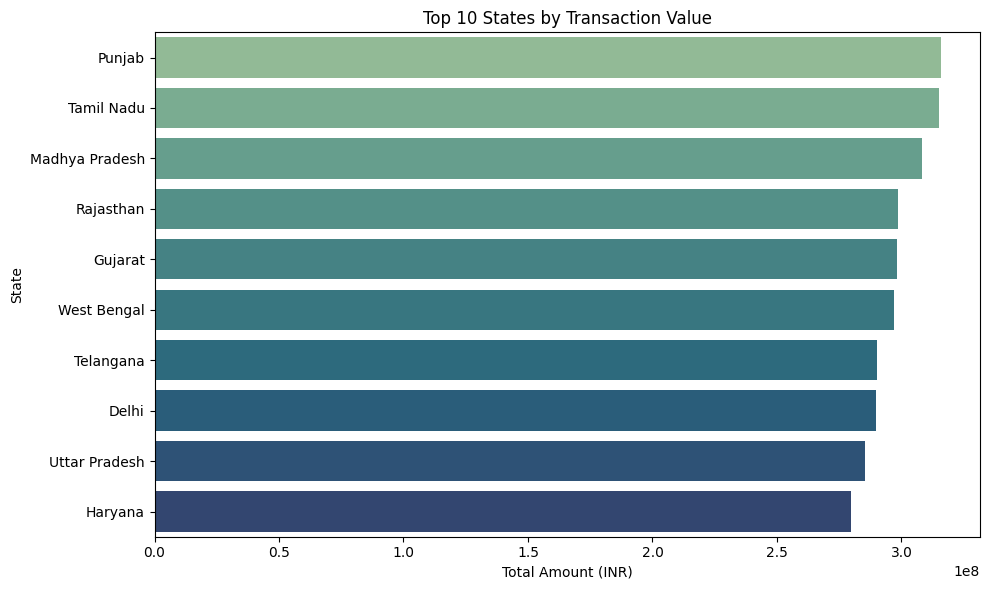

In [36]:
top_states = tx.groupby("state", as_index=False)["amount_inr"].sum().sort_values("amount_inr", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_states, x="amount_inr", y="state", palette="crest")
plt.title("Top 10 States by Transaction Value")
plt.xlabel("Total Amount (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Top 10 States by Transaction Value
This chart highlights the states contributing the highest transaction value.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4196\1576800152.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_nav, x="nav", y="scheme_name", palette="viridis")


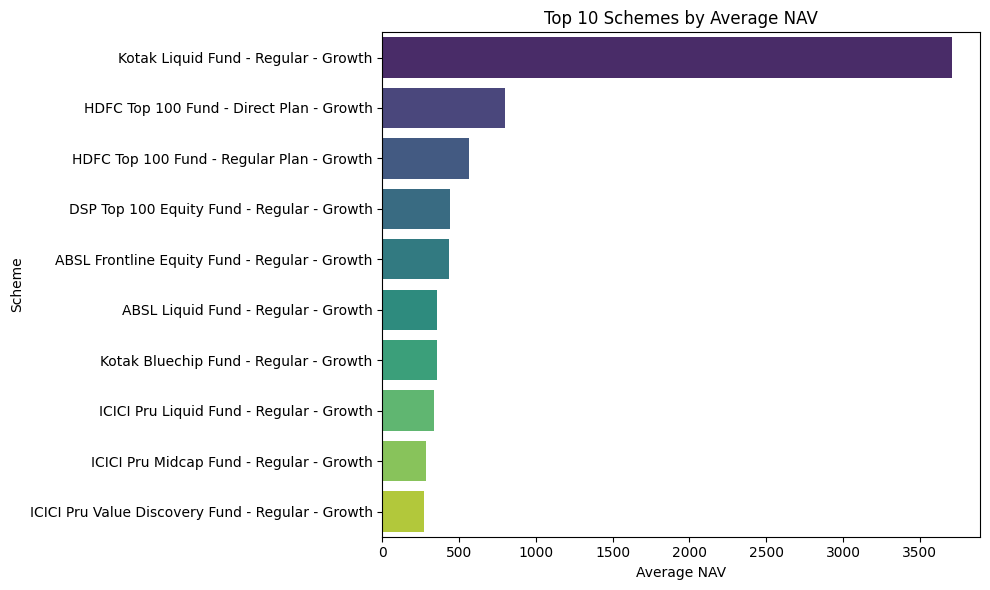

In [37]:
nav = pd.read_csv("data/raw/02_nav_history.csv")
fund_master = pd.read_csv("data/raw/01_fund_master.csv")
nav["date"] = pd.to_datetime(nav["date"])

nav_merged = nav.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
top_nav = nav_merged.groupby("scheme_name", as_index=False)["nav"].mean().sort_values("nav", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_nav, x="nav", y="scheme_name", palette="viridis")
plt.title("Top 10 Schemes by Average NAV")
plt.xlabel("Average NAV")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

### Top 10 Schemes by Average NAV
This bar chart compares the average NAV across the top 10 schemes in the dataset.

## Conclusion
The EDA shows strong industry growth across NAV, AUM, SIP inflows, and folios, while also revealing investor concentration by age, geography, and sector exposure. These insights support the next phases of fund performance analytics and dashboard interpretation.